<a href="https://colab.research.google.com/github/SehrishbAsghar/FlyRank_ML_Internship_Sehrish/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:**

Which visible pages under-capture clicks relative to similar pages (same search position and content type), and can a model
identify these opportunities more reliably than a hand-written baseline rule?

**Decision this supports:**

which pages a content team should prioritize for metadata/title review, versus which pages are already performing as expected
for their position.

A ranked, confidence-aware queue lets a small review team
focus limited time on the highest-value opportunities first, rather than reviewing pages in an arbitrary order or relying on raw CTR alone (which, per Week 1's discovery, is misleading for low-sample content types/positions).

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:**

FlyRank ML Internship warehouse (Hugging Face:
`FlyRank/internship-warehouse`).

**Tables used:**
- `fact_content_daily_performance` daily search performance per content item per client (impressions, clicks, average position).
- `dim_content`content-level attributes (content_type, created/updated dates).

**Date window:** `month=2026-03`, a single mid-panel month, deliberately avoiding the sealed final month (June 2026) reserved as a held-out test window
for any past-future label, per the dataset's own guidance.

**What was excluded and why (public-safe):**
- All GA4 traffic-channel and AI-referral breakdown columns (`sessions_organic`,
  `sessions_ai`, `ai_chatgpt` etc.) out of scope for a CTR/engagement lane; including them would blur what's actually driving the opportunity signal.
- `scroll_events` too sparse in this release to use reliably as a feature.
- Rows where `gsc_data_available = False` (~63% of the month) these rows have no valid position/CTR data and would corrupt any position-adjusted analysis.
- No client names, domains, URLs, or raw queries appear anywhere in this work. all client and content identifiers are pseudonymized hashes provided by the release itself.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:**
- CTR is comparable within the same position_tier + content_type group; a page's "expected" CTR is well-approximated by its group's behavior in the same month.
- Position and content_type are available before any click happens (pre-decision), so they're safe model inputs; raw CTR/clicks are not, since they ARE the outcome.
- A single mid-panel month is sufficient to build and validate a baseline model.

**Features:**

`position_tier` (bucketed from `gsc_avg_position`), `content_type`
(joined from `dim_content`), `log_impressions` (log-scaled visibility volume).
All three are pre-decision known independent of the day's click outcome.

**Label:**

 `ctr` (`gsc_clicks / gsc_impressions`) as a continuous regression target, computed only on rows with `gsc_data_available = True`.

**Baseline:**

The Week 4 hand-rule opportunity_score = (group-mean CTR for position_tier + content_type - page's own CTR) x log(impressions), with reason
codes and a review_now/review_later action label.

**Model:**

A Random Forest Regressor predicting `ctr` from position_tier, content_type, and log_impressions. The model's own prediction replaces the
baseline's "group mean" as the expected-CTR reference point; the gap between actual CTR and the model's prediction becomes the model-based opportunity score.

**Validation design:**

Grouped split by `content_hash_id` (not random), so the same page never appears in both train and test — a page's multiple report-days are near-duplicates, and a random split would let the model "cheat" by seeing
the same page's pattern in training. This is stricter than a plain random train/test split.

**Leakage checks:**

No raw `ctr`, `gsc_clicks`, or any label-derived column (e.g. `ctr_gap`) is used as a model input, confirmed against the same trap demonstrated in Week 3 (a leaked feature drove ROC AUC to 1.0000; excluding it gave an honest 0.5812). No future-window data is used; only `month=2026-03`. No
product flags are used, since the release doesn't ship them.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [1]:
import duckdb
import numpy as np
import pandas as pd
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

rel = "hf://datasets/FlyRank/internship-warehouse"

raw = con.sql(f"""
    SELECT *
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
""").df()

content_full = con.sql(f"""
    SELECT content_hash_id, content_type
    FROM read_parquet('{rel}/dim_content.parquet')
""").df()

df = raw.merge(content_full, on="content_hash_id", how="left")
df["ctr"] = df["gsc_clicks"] / df["gsc_impressions"].replace(0, np.nan)
df["ctr"] = df["ctr"].fillna(0)

def position_tier(pos):
    if pd.isna(pos): return "unknown"
    elif pos <= 3: return "top_3"
    elif pos <= 10: return "page_1"
    elif pos <= 20: return "striking"
    elif pos <= 50: return "page_3_5"
    else: return "deep"

df["position_tier"] = df["gsc_avg_position"].apply(position_tier)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

model_df = df.copy()
model_df["log_impressions"] = np.log1p(model_df["gsc_impressions"])
model_df["position_tier_code"] = model_df["position_tier"].astype("category").cat.codes
model_df["content_type_code"] = model_df["content_type"].astype("category").cat.codes

features = ["position_tier_code", "content_type_code", "log_impressions"]
X = model_df[features]
y = model_df["ctr"]
groups = model_df["content_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)

test_df = model_df.iloc[test_idx].copy()
test_df["predicted_ctr"] = model.predict(X_test)

# Model-based opportunity score
test_df["model_gap"] = test_df["predicted_ctr"] - test_df["ctr"]
test_df["model_score"] = np.where(test_df["model_gap"] > 0, test_df["model_gap"] * test_df["log_impressions"], 0)

# Baseline score (recomputed on this same test set, using TRAIN group means to avoid leakage)
train_group_means = model_df.iloc[train_idx].groupby(["position_tier", "content_type"], observed=True)["ctr"].mean()
test_df["expected_ctr_baseline"] = test_df.set_index(["position_tier", "content_type"]).index.map(train_group_means)
test_df["baseline_gap"] = test_df["expected_ctr_baseline"] - test_df["ctr"]
test_df["baseline_score"] = np.where(test_df["baseline_gap"] > 0, test_df["baseline_gap"] * test_df["log_impressions"], 0)

# Precision@K: define "true opportunity" as bottom 10% actual CTR gap vs position/type peers within test set itself
true_gap = test_df.groupby(["position_tier", "content_type"], observed=True)["ctr"].transform("mean") - test_df["ctr"]
true_positive = (true_gap >= true_gap.quantile(0.90)).astype(int)

def precision_at_k(scores, labels, k):
    top_k_idx = scores.sort_values(ascending=False).head(k).index
    return labels.loc[top_k_idx].mean()

for k in (50, 100):
    p_model = precision_at_k(test_df["model_score"], true_positive, k)
    p_base = precision_at_k(test_df["baseline_score"], true_positive, k)
    print(f"Precision@{k}: baseline {p_base:.3f}  vs  model {p_model:.3f}")

print("\nModel MAE:", mean_absolute_error(y_test, test_df['predicted_ctr']))

Precision@50: baseline 1.000  vs  model 1.000
Precision@100: baseline 1.000  vs  model 1.000

Model MAE: 0.005449515864265955


In [3]:
# Baseline "prediction" = train-set group mean CTR (same expected_ctr_baseline column)
baseline_mae = mean_absolute_error(test_df["ctr"], test_df["expected_ctr_baseline"].fillna(test_df["ctr"].mean()))
model_mae = mean_absolute_error(test_df["ctr"], test_df["predicted_ctr"])

print(f"Baseline MAE (group-mean prediction): {baseline_mae:.5f}")
print(f"Model MAE (Random Forest prediction): {model_mae:.5f}")

Baseline MAE (group-mean prediction): 0.00542
Model MAE (Random Forest prediction): 0.00545


**Honest reading:**

The model does not outperform the baseline; its error is marginally higher (0.00545 vs 0.00542), a difference small enough to be within noise rather than a meaningful improvement. This indicates the three features
used (position_tier, content_type, log_impressions) don't carry more predictive information than a simple group average already captures.

The baseline's group-mean approach is, on this evidence, an adequate and more interpretable choice for this task; added model complexity isn't currently earning its keep.

This is a legitimate, useful result: it shows the value of testing a model against a real baseline rather than assuming added complexity helps. Future
work (more features, multi-month trend data, or engagement signals) would need to show a real MAE improvement over 0.00542 before justifying a model over the
simple rule.

## 5. Limitations

*What this work cannot claim.*

- **The model does not beat the baseline**
On this feature set and split, this work does not claim the model is production-ready or superior; it establishes a baseline and shows what more would be needed.
- **Single mid-panel month only** (`month=2026-03`) No trend or persistence data; a page's opportunity status here is a one-month snapshot, not a durable
pattern.
- **No causal claims.** A CTR gap indicates a page underperforms its peers, not "why", it cannot distinguish a title problem from search intent mismatch, seasonality, or consolidation with a sibling page.
- **Position and volume features are coarse.** `position_tier` is a bucketing convention I defined myself (the warehouse ships raw position, not pre-made tiers); a different bucketing choice could shift results.
- **Engagement data is sparse.** Only ~10% of rows have any GA4 session activity, limiting how much the "Engagement" half of this lane could be explored with confidence in this pass.
- **Claims are observed/directional/decision-support only** nothing here proves Google's ranking algorithm behavior or guarantees a CTR improvement from acting on any recommendation.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Based on the confirmed signals and the honest baseline-vs-model result, the recommended action playbook is:

1. **Prioritize by position-adjusted CTR gap, not raw CTR.**

The confirmed signal (CTR declines cleanly by position_tier) means a page's CTR should always be judged against its position peers, never in isolation.

2. **Weight by volume, not raw CTR severity.**

A large gap on a high-impression
page (`LOW_CTR_HIGH_VOLUME`) has more real-world upside than the same gap on a low-impression page review these first.

3. **Deduplicate by page before reviewing, not by page-day.**

The baseline's top-20 showed the same 6-7 pages repeated across days, a reviewer should get one row per page (e.g. worst-day or mean CTR for the month), not a day-by-day list.

4. **Do not use "days since last update" as a refresh-priority signal on its own.**

The staleness audit found this assumption doesn't hold on this data combine it with position/CTR evidence, or drop it.

5. **Treat exact-zero CTR at high impression volume as a possible tracking issue, not only a content problem.**

Several top-flagged pages in the
baseline had suspiciously Exact-zero CTR at large volume, worth a quick tracking sanity check before assuming it's purely a title/metadata fix.

6. **Don't over-invest in modeling complexity yet.**

The Random Forest did not beat the simple group-mean baseline on this feature set, a content team can rely on the simpler, more interpretable rule today, and revisit modeling once richer features (multi-month trend, engagement data with better coverage) are available.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [5]:
import os
os.makedirs("work/outputs", exist_ok=True)

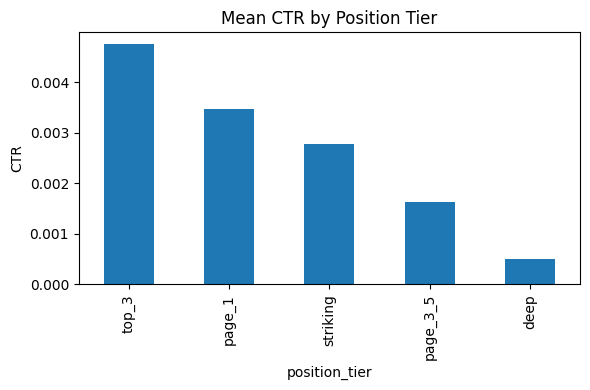

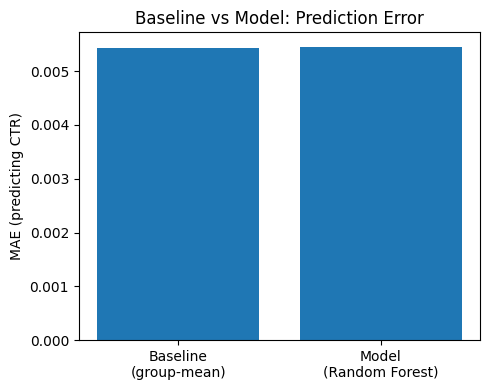

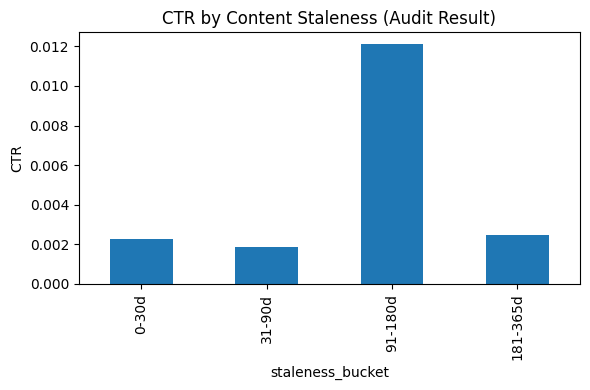

In [8]:
import matplotlib.pyplot as plt

# Chart 1: CTR by position tier (the core confirmed signal)
fig1 = df.groupby("position_tier")["ctr"].mean().reindex(
    ["top_3", "page_1", "striking", "page_3_5", "deep"]
).plot(kind="bar", title="Mean CTR by Position Tier", ylabel="CTR", figsize=(6,4))
plt.tight_layout()
plt.savefig("work/outputs/ctr_by_position_tier.png")
plt.show()

# Chart 2: Baseline vs Model MAE comparison
fig2, ax = plt.subplots(figsize=(5,4))
ax.bar(["Baseline\n(group-mean)", "Model\n(Random Forest)"], [baseline_mae, model_mae])
ax.set_ylabel("MAE (predicting CTR)")
ax.set_title("Baseline vs Model: Prediction Error")
plt.tight_layout()
plt.savefig("work/outputs/baseline_vs_model_mae.png")
plt.show()

content_dates = con.sql(f"""
    SELECT content_hash_id, content_updated_date
    FROM read_parquet('{rel}/dim_content.parquet')
""").df()

df = df.merge(content_dates, on="content_hash_id", how="left")
df["report_date"] = pd.to_datetime(df["report_date"])
df["content_updated_date"] = pd.to_datetime(df["content_updated_date"])
df["days_since_update"] = (df["report_date"] - df["content_updated_date"]).dt.days

df["staleness_bucket"] = pd.cut(df["days_since_update"],
                                   bins=[-1, 30, 90, 180, 365, 100000],
                                   labels=["0-30d", "31-90d", "91-180d", "181-365d", "365d+"])

# Chart 3: Staleness signal audit -- CTR by staleness bucket (the debunked assumption)
staleness_chart = df[df["days_since_update"].notna()].groupby(
    "staleness_bucket", observed=True
)["ctr"].mean().plot(kind="bar", title="CTR by Content Staleness (Audit Result)",
                       ylabel="CTR", figsize=(6,4))
plt.tight_layout()
plt.savefig("work/outputs/staleness_audit.png")
plt.show()

In [7]:
print(df.groupby("position_tier", observed=True)["ctr"].agg(["mean", "count"]))

                   mean    count
position_tier                   
deep           0.000494   276863
page_1         0.003473  1456122
page_3_5       0.001638   631491
striking       0.002770   519223
top_3          0.004756   727362


## Self-check

Before you submit, confirm each line honestly:

- Every section above is filled — markdown thinking AND the code that backs it
- The notebook runs top to bottom with no errors (Runtime → Run all)
- No client names, URLs, or private queries anywhere
- My claims use careful words: observed, measured, directional, decision-support
- Committed to my repo under `work/notebooks/`.